In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

import gridded
from roms_tools import roms_grid_velocity_averages as staggered_avg
import roms_tools as r_tools
import roms_qaqc_plots as r_plot 

In [10]:
# # Next update: incorporate option to automate download/upload of file from Git repo 
# # using "get_datafile", as below. 
# import gnome.scripting as gs
# gs.get_datafile("ROMS_wcofs_May2026_3D.nc", "gridded_test_files/")


ROMS_wcofs_May2026_3D.nc:      100% |################| Time: 0:00:01  18.03 MB/s


'ROMS_wcofs_May2026_3D.nc'

-----------------------------------------------------------------------
### ROMS Arakawa-C grid dimensions 101:
 - RHO .. [M, L]
 - u .... [M, L-1]
 - v .... [M-1, L]
 - psi .. [M-1, L-1]

Once u-velocity is averaged to rho, v, and psi locations,
the original rho, v, and psi grids need to be trimmed accordinginly
in order to align with the value-averaged locations:

 - RHO .. [0:, 1:-1]   -> final dimensions [M, L-2]
 - v .... [0:-1, 1:-1] -> final dimensions [M-1, L-2]
 - psi .. [0:, 0:]     -> final dimensions [M-1, L-1]

Similarly with the v-velocity
 - RHO .. [1:-1, 0:]   -> final dimensions [M-2, L]
 - u .... [1:-1, 0:]    -> final dimensions [M-2, L]
 - psi .. [0:, 0:]      -> final dimensions [M-1, M-1]

-----------------------------------------------------------------------


# Define setup and load ROMS model NetCDF

In [2]:
roms_file = Path("../../gnome_test_files/gridded_test_files/ROMS_wcofs_May2026_3D.nc")
input_file = roms_file
ds = xr.load_dataset(roms_file)
n_t, n_z, n_eta, n_xi = ds["u"].shape
time_index = 0
depth_index = n_z-1

# location of depth transect in "ROMS_calc_z_velocity_errors.py"
eta_index, xi_index = 29, 8

# Average ROMS velocities to staggered grid

In [3]:
gridded_result, u_trim_roms, v_trim_roms = staggered_avg(
    roms_file, 
    time_index = 0,
    depth_index = depth_index, # sfc
    gridded_depth = 0.25
)

 ---  u  --- 
Shape of manual u-avg: (46, 26)
Shape of gridded u-avg: (46, 26)
Shape of lat/lon_u: (46, 26), (46, 26)
Shape of manual v-avg: (44, 26)
Shape of gridded v-avg: (44, 26)
 ---  v  --- 
Shape of manual u-avg: (45, 25)
Shape of gridded u-avg: (45, 25)
Shape of lat/lon_u: (45, 25), (45, 25)
Shape of manual v-avg: (45, 27)
Shape of gridded v-avg: (45, 27)
 ---  rho  --- 
Shape of manual u-avg: (46, 25)
Shape of gridded u-avg: (46, 25)
Shape of lat/lon_u: (46, 25), (46, 25)
Shape of manual v-avg: (44, 27)
Shape of gridded v-avg: (44, 27)
 ---  psi  --- 
Shape of manual u-avg: (45, 26)
Shape of gridded u-avg: (45, 26)
Shape of lat/lon_u: (45, 26), (45, 26)
Shape of manual v-avg: (45, 26)
Shape of gridded v-avg: (45, 26)


# Create maps of current speeds and direction
vectors of ROMS-averaged and gridded results are superimposed

In [4]:
#--- Create maps of current speeds and direction, --
#--- superimposing ROMS-averaged and gridded results ---
for grid_loc in ["u", "v", "rho", "psi"]:
    r_plot.map_roms_error_with_vectors(
        gridded_result[grid_loc],
        time_idx = 0,
        grid_loc = grid_loc
    )

# Validate method using lat/lon averaging
Results are plotted as a 1:1 comparison as a quick, visual check (i.e. results ought to align as a line rather than a scatter of points).

In [5]:
#--- Calculate lat/lon averaging using same method as above ---
#--- and plot comparison to validate this method for a particular grid ---
u_stg, u_lat_stg, u_lon_stg = r_tools.avg_u_to_staggered(
        ds, time_index, depth_index
    )
v_stg, v_lat_stg, v_lon_stg = r_tools.avg_v_to_staggered(
        ds, time_index, depth_index
    )
    
for grid_loc in ["u", "v", "rho", "psi"]: 
    # check u-velocity averaging    
    r_plot.plot_coord_averaging_error(
        roms_file,
        grid_loc,
        "u",
        u_trim_roms,
        u_lat_stg,
        u_lon_stg
    )
    # check v-velocity averaging
    r_plot.plot_coord_averaging_error(
        roms_file,
        grid_loc,
        "v",
        v_trim_roms,
        v_lat_stg,
        v_lon_stg
    )

# Repeat above validation using velocities
The closer to a line the results appear, the less the difference between the ROMS-averaged values and the averaged-values computed in Gridded (unless, of course,  the location is on the variable's grid). 

/Users/rachael.mueller/GNOME/gridded/examples/roms_qaqc_plots.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


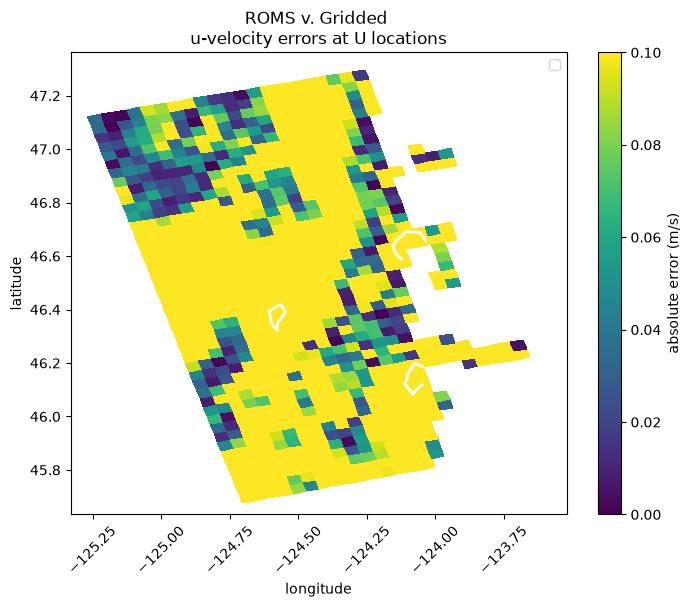

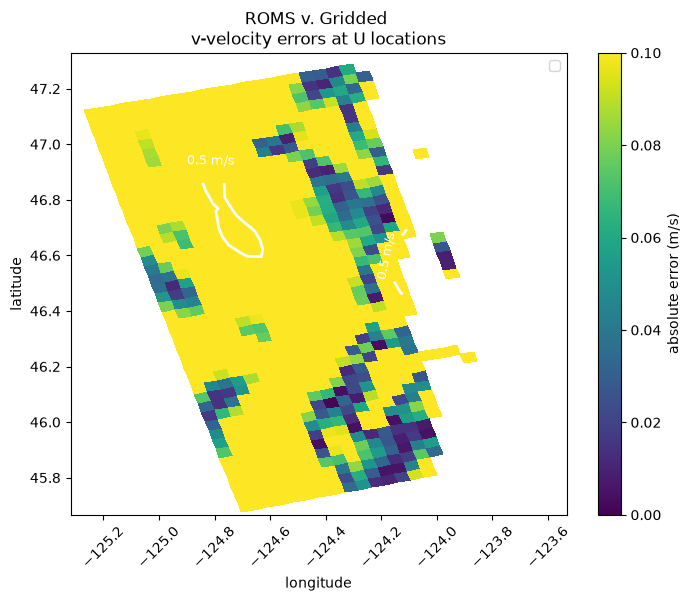

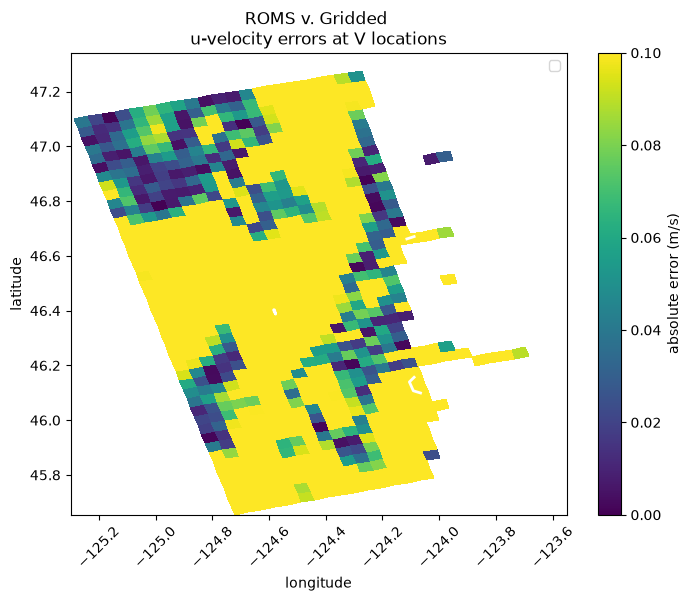

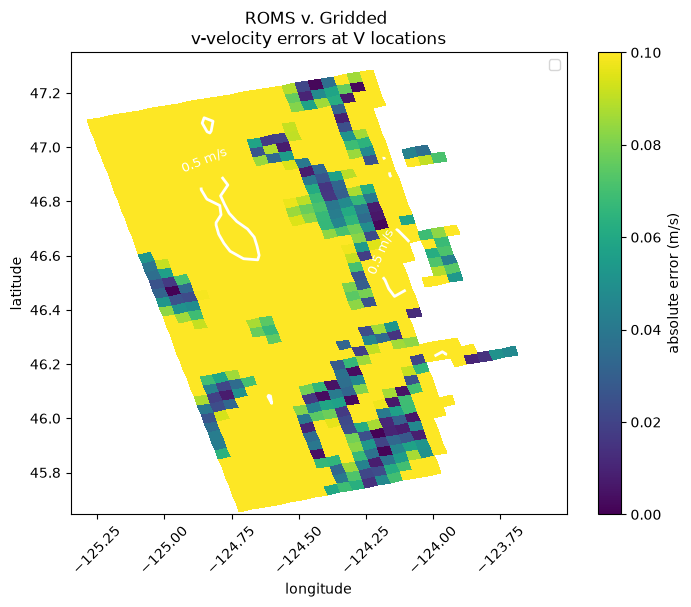

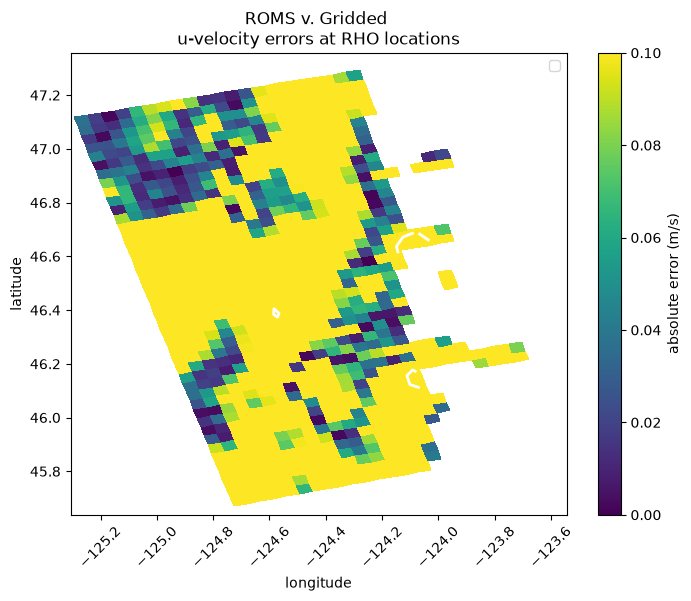

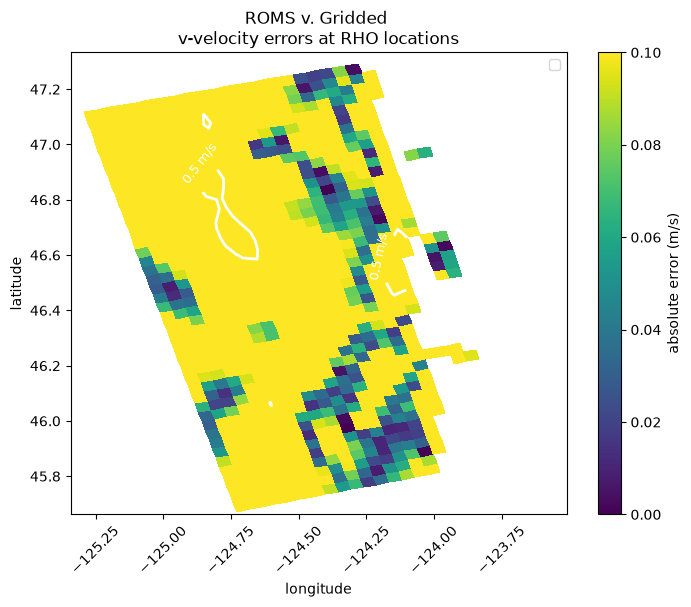

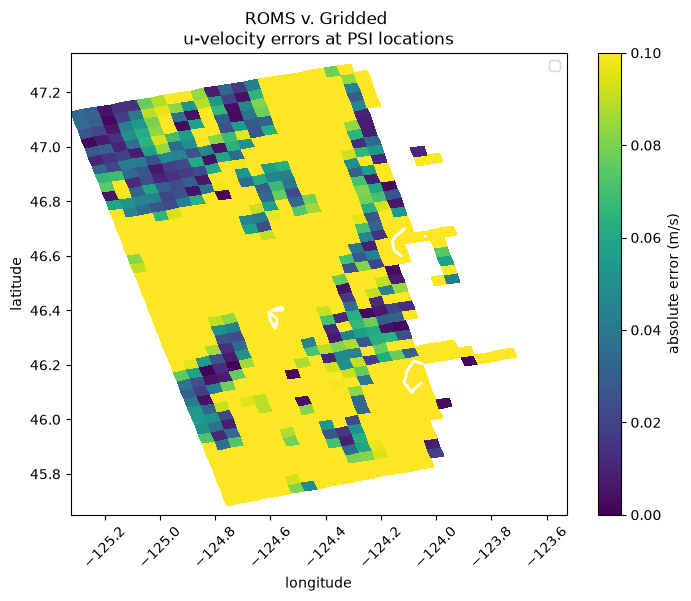

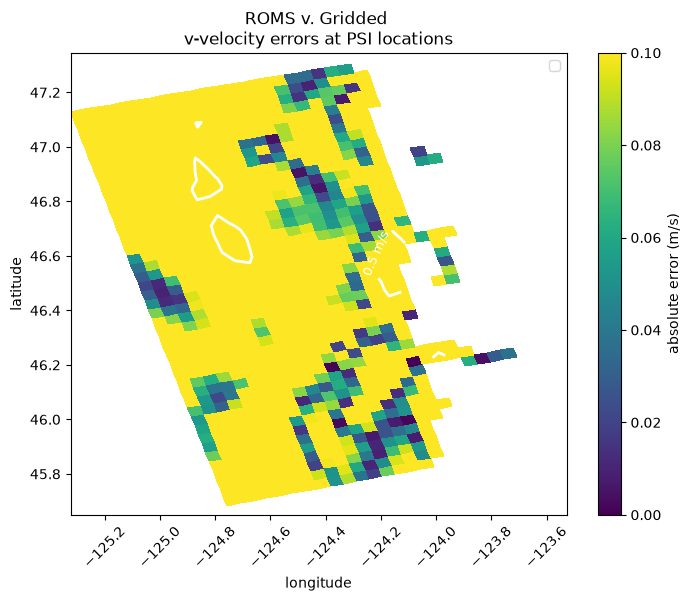

In [6]:
# --- create scatter plot of averaged vs. gridded results ---
n_t = 0
for grid_loc in ["u", "v", "rho", "psi"]: 
    r_plot.plot_velocity_error_scatter(gridded_result[grid_loc], grid_loc)

    for vel_dir in ["u","v"]:
        # --- Compare grid locations ---
        r_plot.plot_coord_error_ROMSaveraging_vs_gridded(
            gridded_result, grid_loc, vel_dir
        )
         # --- Map velocity errors ---
        r_plot.map_roms_error(gridded_result[grid_loc], vel_dir, grid_loc)